# Fuzzy matching de clientes: LemonSuite ↔ Odoo

Reporte reproducible y de **solo lectura** sobre los snapshots locales. No llama APIs ni escribe archivos de salida.

El objetivo es proponer correspondencias auditables, no forzar un match para cada cliente. Se priorizan identificadores y nombres exactos; el fuzzy puro exige un score alto y una separación suficiente frente al segundo candidato.

## Criterio de decisión

1. **Código legacy exacto y único**: match fuerte, salvo contradicción clara de nombres (score < 65).
2. **Código duplicado en Odoo**: siempre queda para revisión; el nombre sólo ordena los candidatos.
3. **Nombre exacto normalizado** (nombre de Odoo o alias Studio): match fuerte si identifica un único partner.
4. **Fuzzy alto**: score ≥ 90 y margen ≥ 7 puntos respecto del segundo candidato.
5. **Fuzzy para revisar**: score ≥ 82 y margen ≥ 5. El resto queda sin match.

La normalización ignora mayúsculas, acentos, puntuación, conectores frecuentes y formas societarias. El universo Odoo incluye `customer_rank > 0` o un identificador LemonSuite/legacy informado; así se excluyen empresas que no son clientes ni tienen señal de integración.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict
from difflib import SequenceMatcher
import json
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 70)

cwd = Path.cwd()
if (cwd / 'data/raw/clients.json').exists():
    DATA = cwd / 'data'
elif (cwd / 'fmdc/data/raw/clients.json').exists():
    DATA = cwd / 'fmdc/data'
else:
    raise FileNotFoundError('No se encontraron los snapshots bajo fmdc/data')

LS_PATH = DATA / 'raw/clients.json'
ODOO_PATH = DATA / 'odoo_export/odoo_clients.csv'

def snapshot_time(path):
    return datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat(timespec='seconds')

display(Markdown(
    f'**Fuentes:** `{LS_PATH}` ({snapshot_time(LS_PATH)}) y '
    f'`{ODOO_PATH}` ({snapshot_time(ODOO_PATH)}), horarios UTC.'
))

**Fuentes:** `/home/mph/odoo-mcp-19/fmdc/data/raw/clients.json` (2026-08-28T21:15:47+00:00) y `/home/mph/odoo-mcp-19/fmdc/data/odoo_export/odoo_clients.csv` (2026-08-28T22:28:44+00:00), horarios UTC.

In [2]:
FALSEISH = {'', 'false', 'none', 'nan', '0'}
STOPWORDS = {'de', 'del', 'la', 'las', 'los', 'el', 'y', 'e', 'en', 'para', 'por', 'un', 'una'}
LEGAL_RE = re.compile(
    r'\b(?:s\.?\s*a\.?\s*i\.?\s*c\.?\s*f\.?\s*i\.?|s\.?\s*a\.?\s*i\.?\s*c\.?|'
    r's\.?\s*a\.?\s*s\.?|s\.?\s*r\.?\s*l\.?|s\.?\s*a\.?|sociedad\s+anonima|'
    r'sociedad\s+de\s+responsabilidad\s+limitada|ltda?\.?|inc\.?|llc)\b',
    flags=re.IGNORECASE,
)

def clean_value(value):
    text = str(value or '').strip()
    return '' if text.lower() in FALSEISH else text

def as_int(value):
    try:
        return int(float(value or 0))
    except (TypeError, ValueError):
        return 0

def normalize_name(value):
    text = unicodedata.normalize('NFKD', clean_value(value))
    text = text.encode('ascii', 'ignore').decode().lower().replace('&', ' y ')
    text = LEGAL_RE.sub(' ', text)
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_code(value):
    text = clean_value(value)
    return str(int(text)) if text.isdigit() else text.lower()

def significant_tokens(text):
    tokens = [token for token in text.split() if token not in STOPWORDS]
    return tokens or text.split()

def ratio(left, right):
    return SequenceMatcher(None, left, right).ratio() if left and right else 0.0

def name_similarity(left, right):
    if not left or not right:
        return 0.0
    if left == right:
        return 100.0
    left_tokens, right_tokens = set(significant_tokens(left)), set(significant_tokens(right))
    shared = left_tokens & right_tokens
    token_sort = ratio(' '.join(sorted(left_tokens)), ' '.join(sorted(right_tokens)))
    if shared:
        common = ' '.join(sorted(shared))
        token_set = max(
            ratio(common, ' '.join(sorted(left_tokens))),
            ratio(common, ' '.join(sorted(right_tokens))),
            token_sort,
        )
    else:
        token_set = 0.0
    return round(100 * max(ratio(left, right), 0.55 * token_sort + 0.45 * token_set), 2)

ls_raw = json.loads(LS_PATH.read_text(encoding='utf-8'))
ls = pd.DataFrame(ls_raw)
odoo_all = pd.read_csv(ODOO_PATH, dtype=str, keep_default_na=False, encoding='utf-8-sig')

ls['_name_norm'] = ls['name'].map(normalize_name)
ls['_code_norm'] = ls['code'].map(normalize_code)
ls['active'] = ls['active'].astype(bool)

odoo_all['_customer_rank_num'] = odoo_all['customer_rank'].map(as_int)
odoo_mask = (
    (odoo_all['_customer_rank_num'] > 0)
    | odoo_all['x_studio_codigo_cliente_legacy'].map(lambda x: bool(clean_value(x)))
    | odoo_all['x_studio_codigo_cliente_lemonsuite'].map(lambda x: bool(clean_value(x)))
)
odoo = odoo_all.loc[odoo_mask].copy().reset_index(drop=True)
odoo['_name_norm'] = odoo['name'].map(normalize_name)
odoo['_studio_norm'] = odoo['x_studio_codigo_cliente_lemonsuite'].map(normalize_name)
odoo['_code_norm'] = odoo['x_studio_codigo_cliente_legacy'].map(normalize_code)

display(pd.DataFrame([
    {'conjunto': 'LemonSuite (total)', 'registros': len(ls)},
    {'conjunto': 'LemonSuite activos', 'registros': int(ls['active'].sum())},
    {'conjunto': 'Odoo exportado', 'registros': len(odoo_all)},
    {'conjunto': 'Odoo universo cliente/integración', 'registros': len(odoo)},
    {'conjunto': 'Odoo con customer_rank > 0', 'registros': int((odoo['_customer_rank_num'] > 0).sum())},
]))

,conjunto,registros
0,LemonSuite (total),480
1,LemonSuite activos,440
2,Odoo exportado,1137
3,Odoo universo cliente/integración,493
4,Odoo con customer_rank > 0,492


In [3]:
# Índices de evidencia exacta. Un partner puede tener nombre principal y alias Studio.
aliases = {}
code_index = defaultdict(list)
exact_index = defaultdict(dict)
for idx, partner in odoo.iterrows():
    partner_aliases = []
    if partner['_name_norm']:
        partner_aliases.append(('nombre_odoo', clean_value(partner['name']), partner['_name_norm']))
    if partner['_studio_norm'] and partner['_studio_norm'] != partner['_name_norm']:
        partner_aliases.append((
            'alias_studio',
            clean_value(partner['x_studio_codigo_cliente_lemonsuite']),
            partner['_studio_norm'],
        ))
    aliases[idx] = partner_aliases
    if partner['_code_norm']:
        code_index[partner['_code_norm']].append(idx)
    for source, raw_alias, normalized_alias in partner_aliases:
        exact_index[normalized_alias].setdefault(idx, (source, raw_alias))

def partner_similarity(query, partner_idx):
    options = [
        (name_similarity(query, alias_norm), source, raw_alias)
        for source, raw_alias, alias_norm in aliases[partner_idx]
    ]
    return max(options, default=(0.0, '', ''), key=lambda item: item[0])

def rank_partners(query, partner_ids=None):
    ids = range(len(odoo)) if partner_ids is None else partner_ids
    ranked = []
    for partner_idx in ids:
        score, source, raw_alias = partner_similarity(query, partner_idx)
        ranked.append((score, partner_idx, source, raw_alias))
    return sorted(ranked, key=lambda item: (-item[0], int(odoo.iloc[item[1]]['id'])))

rows = []
for _, client in ls.iterrows():
    query = client['_name_norm']
    code_hits = code_index.get(client['_code_norm'], []) if client['_code_norm'] else []
    exact_hits = exact_index.get(query, {}) if query else {}

    if code_hits:
        ranked = rank_partners(query, code_hits)
        best = ranked[0]
        runner = ranked[1] if len(ranked) > 1 else None
        if len(code_hits) > 1:
            status, method = 'revisar', 'codigo_duplicado'
        elif best[0] < 65:
            status, method = 'revisar', 'codigo_unico_nombre_discrepa'
        else:
            status, method = 'match_fuerte', 'codigo_exacto_unico'
    elif exact_hits:
        ranked = []
        for partner_idx, (source, raw_alias) in exact_hits.items():
            ranked.append((100.0, partner_idx, source, raw_alias))
        ranked.sort(key=lambda item: int(odoo.iloc[item[1]]['id']))
        best = ranked[0]
        runner = ranked[1] if len(ranked) > 1 else None
        if len(ranked) == 1:
            status, method = 'match_fuerte', f'nombre_exacto_{best[2]}'
        else:
            status, method = 'revisar', 'nombre_exacto_ambiguo'
    else:
        ranked = rank_partners(query)
        best = ranked[0]
        runner = ranked[1] if len(ranked) > 1 else None
        margin = best[0] - (runner[0] if runner else 0.0)
        if best[0] >= 90 and margin >= 7:
            status, method = 'match_fuerte', 'fuzzy_alto'
        elif best[0] >= 82 and margin >= 5:
            status, method = 'revisar', 'fuzzy_revisar'
        else:
            status, method = 'sin_match', 'sin_match'

    best_score, best_idx, alias_source, matched_alias = best
    best_partner = odoo.iloc[best_idx]
    if code_hits or exact_hits:
        margin = best_score - runner[0] if runner else None
    runner_partner = odoo.iloc[runner[1]] if runner else None
    rows.append({
        'ls_id': client['id'],
        'ls_name': client['name'],
        'ls_code': client['code'],
        'ls_active': client['active'],
        'status': status,
        'method': method,
        'name_score': best_score,
        'margin': round(margin, 2) if margin is not None else None,
        'candidate_odoo_id': best_partner['id'],
        'candidate_odoo_name': best_partner['name'],
        'matched_alias_source': alias_source,
        'matched_alias': matched_alias,
        'legacy_code_candidates': len(code_hits),
        'exact_name_candidates': len(exact_hits),
        'second_odoo_id': runner_partner['id'] if runner_partner is not None else '',
        'second_odoo_name': runner_partner['name'] if runner_partner is not None else '',
        'second_score': runner[0] if runner else None,
        'odoo_customer_rank': as_int(best_partner['customer_rank']),
        'odoo_vat_present': bool(clean_value(best_partner['vat'])),
    })

matches = pd.DataFrame(rows)
status_order = ['match_fuerte', 'revisar', 'sin_match']
matches['status'] = pd.Categorical(matches['status'], categories=status_order, ordered=True)
matches = matches.sort_values(['status', 'method', 'name_score'], ascending=[True, True, False]).reset_index(drop=True)
matches.head()

,ls_id,ls_name,ls_code,ls_active,status,method,name_score,margin,candidate_odoo_id,candidate_odoo_name,matched_alias_source,matched_alias,legacy_code_candidates,exact_name_candidates,second_odoo_id,second_odoo_name,second_score,odoo_customer_rank,odoo_vat_present
0,231,17 Sigma,000224,True,match_fuerte,codigo_exacto_unico,100.0,NaN,2132,17 Sigma SRL,nombre_odoo,17 Sigma SRL,1,1,,,NaN,1,True
1,378,ALFA BETA,000367,True,match_fuerte,codigo_exacto_unico,100.0,NaN,2145,ALFA BETA SISTEMAS SA,alias_studio,ALFA BETA,1,1,,,NaN,15,True
2,234,Assist Med,000227,True,match_fuerte,codigo_exacto_unico,100.0,NaN,2553,Assit Med Srl,alias_studio,Assist Med,1,1,,,NaN,1,True
3,39,BIOCODICES,000039,True,match_fuerte,codigo_exacto_unico,100.0,NaN,2172,BIOCODICES S.A.,nombre_odoo,BIOCODICES S.A.,1,1,,,NaN,1,True
4,334,BODUM AUSSENHANDELS GMBH,000323,True,match_fuerte,codigo_exacto_unico,100.0,NaN,2179,Bodum Aussenhandels GmbH,nombre_odoo,Bodum Aussenhandels GmbH,1,1,,,NaN,1,True


,métrica,valor,porcentaje
0,Clientes LemonSuite,480,100.0%
1,Match fuerte,117,24.4%
2,Revisar,38,7.9%
3,Sin match,325,67.7%
4,Match fuerte (sólo LS activos),107,24.3%
5,Fuerte + revisar (sólo LS activos),140,31.8%


### Desglose por método

,status,method,clientes
3,match_fuerte,nombre_exacto_nombre_odoo,52
0,match_fuerte,codigo_exacto_unico,38
1,match_fuerte,fuzzy_alto,16
2,match_fuerte,nombre_exacto_alias_studio,11
4,revisar,codigo_duplicado,14
6,revisar,fuzzy_revisar,13
5,revisar,codigo_unico_nombre_discrepa,9
7,revisar,nombre_exacto_ambiguo,2
8,sin_match,sin_match,325


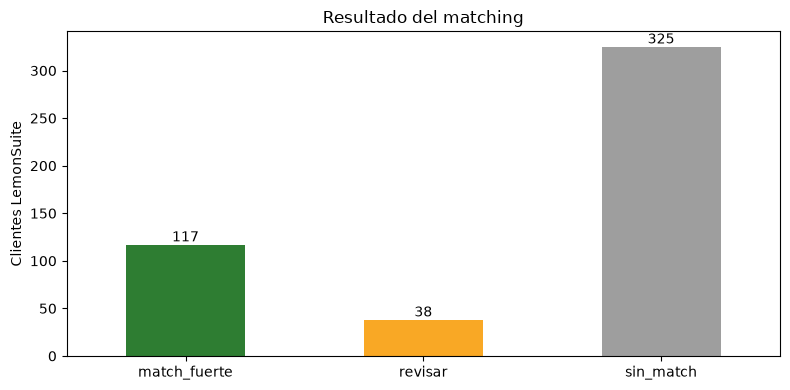

In [4]:
status_counts = matches['status'].value_counts().reindex(status_order, fill_value=0)
method_counts = (
    matches.groupby(['status', 'method'], observed=True)
    .size().rename('clientes').reset_index()
    .sort_values(['status', 'clientes'], ascending=[True, False])
)

strong = matches[matches['status'] == 'match_fuerte']
review = matches[matches['status'] == 'revisar']
unmatched = matches[matches['status'] == 'sin_match']
strong_active = strong[strong['ls_active']]
review_active = review[review['ls_active']]

summary = pd.DataFrame([
    {'métrica': 'Clientes LemonSuite', 'valor': len(matches), 'porcentaje': 100.0},
    {'métrica': 'Match fuerte', 'valor': len(strong), 'porcentaje': 100 * len(strong) / len(matches)},
    {'métrica': 'Revisar', 'valor': len(review), 'porcentaje': 100 * len(review) / len(matches)},
    {'métrica': 'Sin match', 'valor': len(unmatched), 'porcentaje': 100 * len(unmatched) / len(matches)},
    {'métrica': 'Match fuerte (sólo LS activos)', 'valor': len(strong_active), 'porcentaje': 100 * len(strong_active) / int(matches['ls_active'].sum())},
    {'métrica': 'Fuerte + revisar (sólo LS activos)', 'valor': len(strong_active) + len(review_active), 'porcentaje': 100 * (len(strong_active) + len(review_active)) / int(matches['ls_active'].sum())},
])
summary['porcentaje'] = summary['porcentaje'].map(lambda x: f'{x:.1f}%')
display(summary)
display(Markdown('### Desglose por método'))
display(method_counts)

colors = ['#2E7D32', '#F9A825', '#9E9E9E']
ax = status_counts.plot(kind='bar', color=colors, figsize=(8, 4), rot=0, title='Resultado del matching')
ax.set_xlabel('')
ax.set_ylabel('Clientes LemonSuite')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## Casos para revisión

La tabla siguiente es la cola accionable. Los conflictos de código aparecen primero, luego ambigüedades exactas y candidatos fuzzy. `matched_alias_source` aclara si la evidencia vino del nombre visible de Odoo o del campo Studio.

In [5]:
review_columns = [
    'ls_id', 'ls_name', 'ls_code', 'ls_active', 'method', 'name_score', 'margin',
    'candidate_odoo_id', 'candidate_odoo_name', 'matched_alias_source', 'matched_alias',
    'legacy_code_candidates', 'second_odoo_id', 'second_odoo_name', 'second_score',
]
review_priority = {
    'codigo_unico_nombre_discrepa': 0,
    'codigo_duplicado': 1,
    'nombre_exacto_ambiguo': 2,
    'fuzzy_revisar': 3,
}
review_table = review.assign(_priority=review['method'].map(review_priority)).sort_values(
    ['_priority', 'name_score'], ascending=[True, False]
)[review_columns]
display(review_table)

,ls_id,ls_name,ls_code,ls_active,method,name_score,margin,candidate_odoo_id,candidate_odoo_name,matched_alias_source,matched_alias,legacy_code_candidates,second_odoo_id,second_odoo_name,second_score
131,23,MIGUEL MENDOZA,000023,True,codigo_unico_nombre_discrepa,53.33,NaN,2178,Santa Rosa de Chivilcoy SA,alias_studio,FAMILIA BENGOLEA,1,,,NaN
132,38,AGROPECUARIA LOS AMANECERES,000038,False,codigo_unico_nombre_discrepa,52.31,NaN,2277,ESTABLECIMIENTO AGROPECUARIO EL AGUARA SA,nombre_odoo,ESTABLECIMIENTO AGROPECUARIO EL AGUARA SA,1,,,NaN
133,21,TILO PAMPA,000021,True,codigo_unico_nombre_discrepa,37.50,NaN,2531,TUBOS ARGENTINOS SA,alias_studio,INTASA,1,,,NaN
134,15,LAUREATE EDUCATION,000015,True,codigo_unico_nombre_discrepa,33.33,NaN,2229,DESDE EL SUR SA,nombre_odoo,DESDE EL SUR SA,1,,,NaN
135,18,FAMILIA SALOVAARA-STEWART,000018,True,codigo_unico_nombre_discrepa,29.79,NaN,2433,Mati identity services,nombre_odoo,Mati identity services,1,,,NaN
136,36,MICHEL DE SAIZIEU,000036,False,codigo_unico_nombre_discrepa,28.57,NaN,2452,PABLO BRAUN,nombre_odoo,PABLO BRAUN,1,,,NaN
137,31,PRINCZ,000031,True,codigo_unico_nombre_discrepa,28.57,NaN,2336,IN. DE. UR. S.R.L.,nombre_odoo,IN. DE. UR. S.R.L.,1,,,NaN
138,16,LLOYDS TSB BANK PLC,000016,True,codigo_unico_nombre_discrepa,25.00,NaN,2264,ESTANCIAS DON PEDRO Y LA ROSA S.A,nombre_odoo,ESTANCIAS DON PEDRO Y LA ROSA S.A,1,,,NaN
139,27,FISERV,000027,True,codigo_unico_nombre_discrepa,15.38,NaN,2496,SCENTIA SRL,nombre_odoo,SCENTIA SRL,1,,,NaN
117,29,ANDRES LUGANO,000029,True,codigo_duplicado,100.00,0.00,2162,Albarracín Facundo Alberto,alias_studio,ANDRES LUGANO,3,2354,SUC. ANDRES M. LUGANO,100.00


## Matches fuzzy fuertes

Estos casos no dependen de código ni de igualdad exacta. Se muestran completos para poder validar si el umbral automático resulta razonable.

In [6]:
fuzzy_strong = strong[strong['method'] == 'fuzzy_alto'][[
    'ls_id', 'ls_name', 'ls_active', 'name_score', 'margin', 'candidate_odoo_id',
    'candidate_odoo_name', 'matched_alias_source', 'matched_alias', 'second_odoo_name', 'second_score',
]].sort_values('name_score', ascending=False)
display(fuzzy_strong)

,ls_id,ls_name,ls_active,name_score,margin,candidate_odoo_id,candidate_odoo_name,matched_alias_source,matched_alias,second_odoo_name,second_score
38,460,Banco Provincia de Neuquén,True,100.00,44.10,24482,BANCO PROVINCIA DEL NEUQUEN S.A.,nombre_odoo,BANCO PROVINCIA DEL NEUQUEN S.A.,PROVINCIA SEGUROS SA,55.90
39,288,RODRIGO CRUCES,True,100.00,42.86,2218,Cruces Rodrigo,nombre_odoo,Cruces Rodrigo,Resio Federico Carlos,57.14
40,2,ACM - ANALISIS DE COYUNTURA MACROECONOMICA CONSULTORA Y DE MANDATO,True,97.96,52.44,2136,ANALISIS DE COYUNTURA MACROECONOMICA CONSULTORA Y DE MANDATO,nombre_odoo,ANALISIS DE COYUNTURA MACROECONOMICA CONSULTORA Y DE MANDATO,CONSULTORA DE ESTUDIOS BONAERENSE S.A.,45.52
41,169,Anselmo Morvillo,False,96.76,48.48,2163,ANSELMO L MORVILLO,nombre_odoo,ANSELMO L MORVILLO,AUTO EMPORIUM SRL,48.28
42,261,Miguel Murray,True,96.07,10.21,2417,Miguel V. Murray,nombre_odoo,Miguel V. Murray,MURRAY MIGUEL PATRICIO,85.86
43,61,NANCY SARGENT,True,96.07,31.78,2495,NANCY L. SARGENT,nombre_odoo,NANCY L. SARGENT,INESA ARGENTINA SA,64.29
44,66,GREENBERG TRAURIG,True,95.54,43.69,2308,GREENBERG TRAURIG PA,nombre_odoo,GREENBERG TRAURIG PA,De Ferrari,51.85
45,123,Concesionaria Cruz del Sur S.A.,False,94.39,12.85,2202,CONCESIONARIA VIAL CRUZ DEL SUR SA,nombre_odoo,CONCESIONARIA VIAL CRUZ DEL SUR SA,COVISUR SA CONCESIONARIA VIAL DEL SUR SA,81.54
46,24,Ala Este,True,94.12,23.53,24465,Alas Este SAS,nombre_odoo,Alas Este SAS,ALFA BETA SISTEMAS SA,70.59
47,30,HENRY ROURKE,True,93.89,7.64,2243,Mr. Henry Rourke,nombre_odoo,Mr. Henry Rourke,HENRY CHARLES ROURKE,86.25


## Controles de calidad

Se revisan asignaciones muchos-a-uno, cobertura del universo Odoo y los mejores candidatos que quedaron debajo del umbral. Una asignación muchos-a-uno no es necesariamente incorrecta (puede representar un grupo económico), pero requiere validación.

In [7]:
strong_duplicates = (
    strong.groupby(['candidate_odoo_id', 'candidate_odoo_name'], dropna=False)
    .agg(ls_clients=('ls_id', 'size'), ls_names=('ls_name', lambda values: ' | '.join(map(str, values))))
    .reset_index()
    .query('ls_clients > 1')
    .sort_values('ls_clients', ascending=False)
)
unique_strong_odoo = strong['candidate_odoo_id'].nunique()
odoo_customer_count = int((odoo['_customer_rank_num'] > 0).sum())

quality = pd.DataFrame([
    {'control': 'Partners Odoo únicos con match fuerte', 'valor': unique_strong_odoo},
    {'control': 'Cobertura fuerte sobre clientes Odoo', 'valor': f'{100 * unique_strong_odoo / odoo_customer_count:.1f}%'},
    {'control': 'Partners Odoo con >1 cliente LS fuerte', 'valor': len(strong_duplicates)},
    {'control': 'Códigos legacy duplicados en Odoo', 'valor': sum(len(ids) > 1 for ids in code_index.values())},
    {'control': 'Clientes LS con código único pero nombre contradictorio', 'valor': int((matches['method'] == 'codigo_unico_nombre_discrepa').sum())},
])
display(quality)
display(Markdown('### Asignaciones muchos-a-uno entre los matches fuertes'))
display(strong_duplicates if len(strong_duplicates) else Markdown('_No se detectaron._'))

display(Markdown('### Mejores candidatos entre los casos sin match (sólo orientación)'))
near_misses = unmatched.sort_values(['name_score', 'margin'], ascending=False)[[
    'ls_id', 'ls_name', 'ls_active', 'name_score', 'margin',
    'candidate_odoo_id', 'candidate_odoo_name', 'matched_alias_source', 'matched_alias',
]].head(30)
display(near_misses)

,control,valor
0,Partners Odoo únicos con match fuerte,113
1,Cobertura fuerte sobre clientes Odoo,23.0%
2,Partners Odoo con >1 cliente LS fuerte,4
3,Códigos legacy duplicados en Odoo,14
4,Clientes LS con código único pero nombre contradictorio,9


### Asignaciones muchos-a-uno entre los matches fuertes

,candidate_odoo_id,candidate_odoo_name,ls_clients,ls_names
5,2163,ANSELMO L MORVILLO,2,Anselmo Morvillo | Anselmo Mordillo
25,2264,ESTANCIAS DON PEDRO Y LA ROSA S.A,2,FAMILIA BERISSO | ESTANCIAS DON PEDRO Y LA ROSA
32,2303,GR GENERACION GLOBAL S.A.,2,GR GENERACIÓN ENERGÉTICA ARGENTINA | GR GENERACION GLOBAL
109,2554,Agropecuaria IBIS SA Agrícola Ganadera e inmobiliaria,2,FAMILIA DOWNEY | Familia Dawney


### Mejores candidatos entre los casos sin match (sólo orientación)

,ls_id,ls_name,ls_active,name_score,margin,candidate_odoo_id,candidate_odoo_name,matched_alias_source,matched_alias
155,189,HCL ARGENTINA,True,84.62,2.05,2320,HSM ARGENTINA S.A.,nombre_odoo,HSM ARGENTINA S.A.
156,156,Grupo GC,True,82.35,0.00,2158,FIDEICOMISO DE ADMINISTRACION PARK 10 BUENAVISTA,alias_studio,GRUPO TRG
157,70,DELAWARE GROUP,True,81.89,19.39,2225,"DELAWARE US, LLC",nombre_odoo,"DELAWARE US, LLC"
159,415,SEBASTIAN DEMONTE,True,81.67,23.78,2448,OPTIMIA SAS,alias_studio,Familia Demonte / Santiago Demonte / SEBASTIAN DEMONTE
158,28,AGROPROGRESO,True,81.67,17.67,2142,AGROPROGRESO CORPORATION S.A.,nombre_odoo,AGROPROGRESO CORPORATION S.A.
160,222,URANGA,True,81.67,10.27,2540,URANGA MARIA,nombre_odoo,URANGA MARIA
161,20,FAMILIA EIJO,True,81.48,0.00,2217,Cornejo Santiago,alias_studio,FAMILIA CORNEJO
162,461,FAMILIA EMBON,True,81.48,0.00,2434,Moyano Hersilia Maria,alias_studio,FAMILIA MOYANO
163,195,Santiago Demonte,True,80.20,11.45,2448,OPTIMIA SAS,alias_studio,Familia Demonte / Santiago Demonte / SEBASTIAN DEMONTE
164,476,CENTRO DE SERV. HOSPITALARIOS (PIQUERAS),True,80.00,21.76,2188,CENTRO DE SERVICIOS HOSPITALARIOS S.A.,nombre_odoo,CENTRO DE SERVICIOS HOSPITALARIOS S.A.


## Resultado completo

`matches` contiene las 480 filas y todas las columnas de auditoría. La vista se ordena por estado, método y score. El notebook no exporta ni modifica datos; si más adelante se autoriza una salida operativa, este DataFrame es la fuente indicada.

In [8]:
display(matches)

,ls_id,ls_name,ls_code,ls_active,status,method,name_score,margin,candidate_odoo_id,candidate_odoo_name,matched_alias_source,matched_alias,legacy_code_candidates,exact_name_candidates,second_odoo_id,second_odoo_name,second_score,odoo_customer_rank,odoo_vat_present
0,231,17 Sigma,000224,True,match_fuerte,codigo_exacto_unico,100.00,NaN,2132,17 Sigma SRL,nombre_odoo,17 Sigma SRL,1,1,,,NaN,1,True
1,378,ALFA BETA,000367,True,match_fuerte,codigo_exacto_unico,100.00,NaN,2145,ALFA BETA SISTEMAS SA,alias_studio,ALFA BETA,1,1,,,NaN,15,True
2,234,Assist Med,000227,True,match_fuerte,codigo_exacto_unico,100.00,NaN,2553,Assit Med Srl,alias_studio,Assist Med,1,1,,,NaN,1,True
3,39,BIOCODICES,000039,True,match_fuerte,codigo_exacto_unico,100.00,NaN,2172,BIOCODICES S.A.,nombre_odoo,BIOCODICES S.A.,1,1,,,NaN,1,True
4,334,BODUM AUSSENHANDELS GMBH,000323,True,match_fuerte,codigo_exacto_unico,100.00,NaN,2179,Bodum Aussenhandels GmbH,nombre_odoo,Bodum Aussenhandels GmbH,1,1,,,NaN,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,212,RBS,000205,True,sin_match,sin_match,40.00,0.00,2143,AGROSOL SA,nombre_odoo,AGROSOL SA,0,0,2326,INCUBUS S.A.,40.00,1,True
476,354,Wuru,000343,True,sin_match,sin_match,40.00,0.00,2213,Conuar Sa (combustibles nucleares argentinos),alias_studio,CONUAR,0,0,24541,WORLEY ARGENTINA S.A.,40.00,18,True
477,390,XLC,000379,True,sin_match,sin_match,40.00,3.64,2252,ELOCOTE SOCIEDAD ANONIMA,nombre_odoo,ELOCOTE SOCIEDAD ANONIMA,0,0,2433,Mati identity services,36.36,1,True
478,376,SF 500,000365,True,sin_match,sin_match,30.77,0.00,2422,MSU AIR S.A.,nombre_odoo,MSU AIR S.A.,0,0,2423,MSU OVO S.A.,30.77,1,True
